## Install Dependencies

In [1]:
!uv pip install syftbox-enclave syft-rds==0.1.1-dev.5

Audited 2 packages in 8ms


# Remote Data Science Flow: Organic Coop

This notebook demonstrates a secure data sharing scenario where:

- **Data Owner**: Farmer
- **Data Scientist**: Organic Coop Head

**Dataset**: Contains the Organic Crop Stock Data which is uploaded by the farmers

**Use Case**: The Organic Coop Head would like to run statistical queries on the data uploaded by the farmers in a privacy preserving manner

---
# 0. Both department install SyftBox on their premise & the syft-rds app

Nothing here to show.

---
# 1. Farmer Uploads Data

The Farmers could either:

1. 

    - a dataset containing organic crop data  
    - a mock counterpart  
    - a data card explaining the schema and data collection  

or  

2. Connect to their existing online store (ex: Shopify , Square API) 

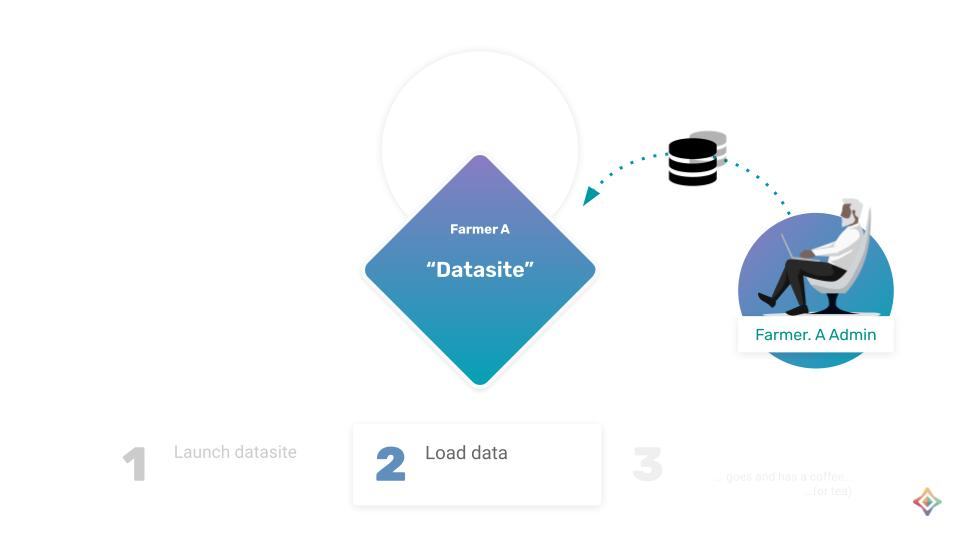

---
# 2. Research from Organic Coop accesses the dataset

Researcher can view available datasets and access mock data for development and testing of their analysis code.

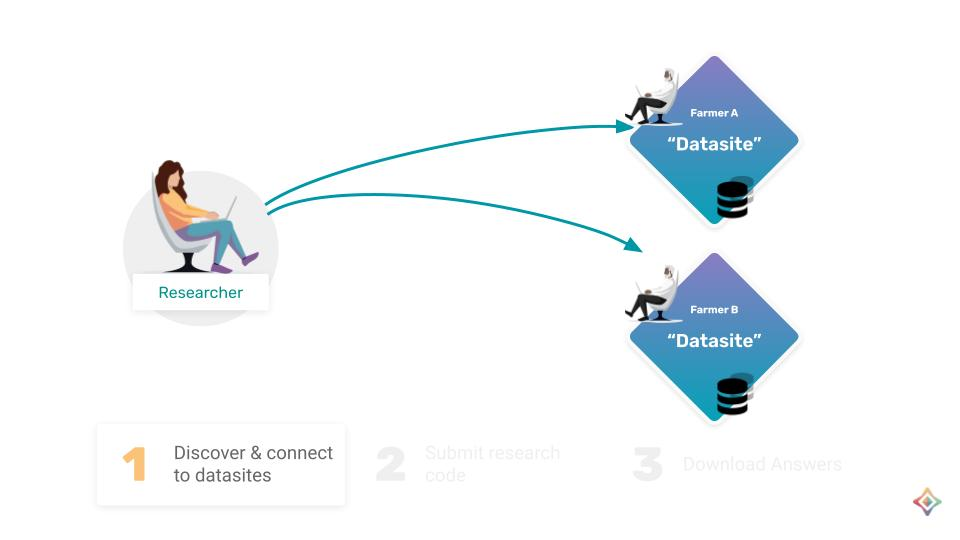

In [2]:
from syft_rds import init_session
from syft_core import Client

In [5]:
DATA_OWNERS = [
            "<DO1_EMAIL>"
              ]
DATA_SCIENTIST = [ Client.load().email ]

In [6]:
ds_clients = []

for do in DATA_OWNERS:
    ds_client = init_session(do)
    ds_clients.append(ds_client)
    print(f"Logged into {ds_client.host}")


Logged into rasswanth@openmined.org


In [7]:
datasets = []

# We could either index the datasets
for ds_client in ds_clients:
    datasets.append(ds_client.datasets[0])
    
    

In [8]:
datasets

[Dataset
   uid: 9637ccb5-4f6b-4d8f-9462-08ab1ffac427
   created_by: None
   created_at: 2025-07-18T14:54:45.903605Z
   updated_at: 2025-07-18T14:54:45.903607Z
   client_id: fbc15354-1352-4e85-b427-aec0941b050b
   name: Organic Crop Stock Data
   private: syft://rasswanth@openmined.org/private/datasets/Organic Crop Stock Data
   mock: syft://rasswanth@openmined.org/public/datasets/Organic Crop Stock Data
   summary: 
   readme: syft://rasswanth@openmined.org/public/datasets/Organic Crop Stock Data/dummy_description.txt
   tags: []
   runtime: {'cmd': ['python'], 'image_name': None, 'mount_dir': None}
   auto_approval: ['rasswanth@openmined.org']]

### Inspect the data and inform their analysis



In [9]:
# Inspect the mock data of all datasets

import pandas as pd
from pathlib import Path
from IPython.display import display

for dataset in datasets:
    mock_path = dataset.get_mock_path()
    mock_csv_path = list(Path(mock_path).glob("*.csv"))[0]
    df_mock = pd.read_csv(mock_csv_path)
    
    display(df_mock.head(3))
    print("\n\n\n")
    

,ID,Product name,Quantity,Price ($),Unit
0,U1399,Radishes,121,410.75,kgs
1,U9734,Kale,450,1194.47,kgs
2,U4696,Spinach,88,143.86,kgs


### Propose analysis

In [10]:

code_path = Path(".") / "code"
code_path.mkdir(exist_ok=True)

code_file_name  = "crop_analysis.py"
code_file_path = code_path / code_file_name

In [11]:
%%writefile {code_file_path}

import os
from pathlib import Path
from sys import exit

import pandas as pd

DATA_DIR = os.environ["DATA_DIR"]
OUTPUT_DIR = os.environ["OUTPUT_DIR"]

dataset_paths = [Path(dataset_path) for dataset_path in DATA_DIR.split(",")]
csv_paths = []
for dataset_path in dataset_paths:
    csv_paths.extend(list(Path(dataset_path).glob("*.csv")))

total_carrots = 0
total_tomatoes = 0

for csv_path in csv_paths:
    if not csv_path.exists():
        print(f"Warning: CSV path does not exist: {csv_path}")
        exit(1)
    df = pd.read_csv(csv_path)
    total_carrots += df[df["Product name"] == "Carrots"]["Quantity"].sum()
    total_tomatoes += df[df["Product name"] == "Tomatoes"]["Quantity"].sum()

print(f"Total Carrots: {total_carrots}\n")
print(f"Total Tomatoes: {total_tomatoes}\n")

# Create output DataFrame with the same columns as original
output_df = pd.DataFrame({
    "Product name": ["Carrots", "Tomatoes"],
    "Quantity": [total_carrots, total_tomatoes]
})

# Write to CSV
output_csv_path = os.path.join(OUTPUT_DIR, "output.csv")
output_df.to_csv(output_csv_path, index=False)

Overwriting code/crop_analysis.py


### Test the analysis code against mock data

Before submitting the code for review, Treasury can test their analysis against the Department of Health mock data to ensure it works correctly.


In [12]:
# Test against mock of all datasets

import subprocess, tempfile, os
from IPython.display import display

with tempfile.TemporaryDirectory() as temp_dir:
    env = os.environ.copy()
    env.update({'DATA_DIR': ",".join([ str(dataset.get_mock_path()) for dataset in datasets]), 'OUTPUT_DIR': temp_dir})
    
    result = subprocess.run(["python", str(code_file_path)], env=env, capture_output=True, text=True)

    output_csv_path = Path(temp_dir) / "output.csv"
    df = pd.read_csv(output_csv_path)
    print("\n")
    display(df)
    print("\n\n")

,Product name,Quantity
0,Carrots,0
1,Tomatoes,89


---
# 3. Researcher submits analysis code

Researcher submits the Analysis code to the Data Owners (Farmers) to be able to run on enclaves

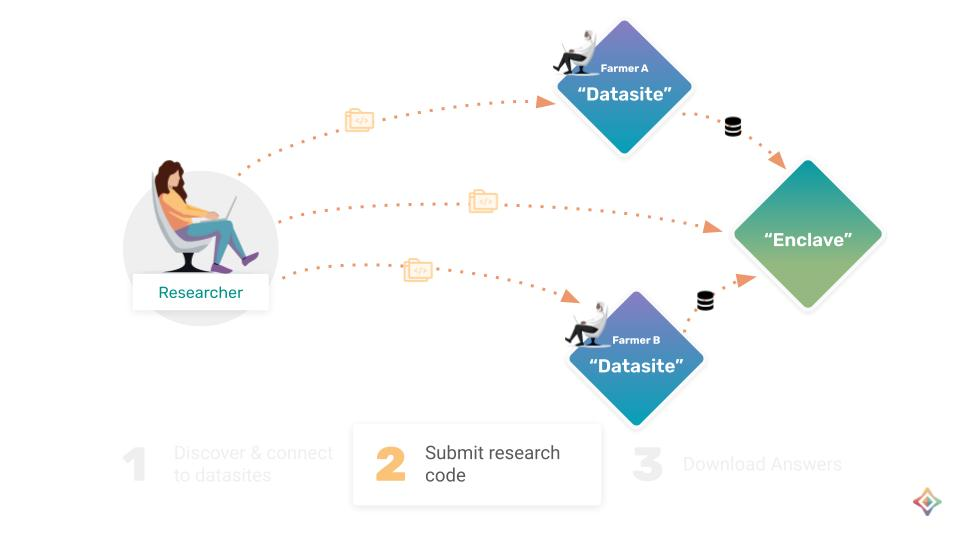

In [13]:
from uuid import uuid4

# Generate 
RANDOM_ID = str(uuid4())[0:8]
JOB_NAME = f"Test Job - {RANDOM_ID}"

print("Job Name:", JOB_NAME)

Job Name: Test Job - 86f7833c


In [14]:
ENCLAVE = "enclave-organic-coop@openmined.org"

jobs = []

for ds_client, dataset in zip(ds_clients, datasets):
    job = ds_client.jobs.submit(
                name=JOB_NAME,
                description="Organic Coop Experiment",
                user_code_path=code_path,
                dataset_name=dataset.name,
                entrypoint = code_file_name,
                enclave = ENCLAVE
            )
    job.describe()
    jobs.append(job)

uid,9b5c712a-9463-499d-80c7-9acf80341734
created_by,rasswanth@openmined.org
created_at,2025-07-18 15:36:17
updated_at,2025-07-18 15:36:17
name,Test Job - 86f7833c
description,Organic Coop Experiment
status,pending_code_review
error,no_error
error_message,None
output_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/app_data/RDS/user_files/rasswanth@openmined.org/Job/9b5c712a-9463-499d-80c7-9acf80341734
dataset_name,Organic Crop Stock Data


In [15]:
ds_clients[0].jobs.get(name=JOB_NAME).describe()

uid,9b5c712a-9463-499d-80c7-9acf80341734
created_by,rasswanth@openmined.org
created_at,2025-07-18 15:36:17
updated_at,2025-07-18 15:36:17
name,Test Job - 86f7833c
description,Organic Coop Experiment
status,approved
error,no_error
error_message,None
output_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/app_data/RDS/user_files/rasswanth@openmined.org/Job/9b5c712a-9463-499d-80c7-9acf80341734
dataset_name,Organic Crop Stock Data


## Enclave Client

In [16]:
from syftbox_enclave import connect

In [17]:
enclave_client = connect(ENCLAVE)

In [18]:
PROJECT_NAME = f"Test Project - {RANDOM_ID}"

print("Project Name:", PROJECT_NAME)

Project Name: Test Project - 86f7833c


In [19]:
datasets

[Dataset
   uid: 9637ccb5-4f6b-4d8f-9462-08ab1ffac427
   created_by: None
   created_at: 2025-07-18T14:54:45.903605Z
   updated_at: 2025-07-18T14:54:45.903607Z
   client_id: fbc15354-1352-4e85-b427-aec0941b050b
   name: Organic Crop Stock Data
   private: syft://rasswanth@openmined.org/private/datasets/Organic Crop Stock Data
   mock: syft://rasswanth@openmined.org/public/datasets/Organic Crop Stock Data
   summary: 
   readme: syft://rasswanth@openmined.org/public/datasets/Organic Crop Stock Data/dummy_description.txt
   tags: []
   runtime: {'cmd': ['python'], 'image_name': None, 'mount_dir': None}
   auto_approval: ['rasswanth@openmined.org']]

In [20]:

proj_res = enclave_client.create_project(
                   project_name = PROJECT_NAME,
                   datasets = datasets,
                   output_owners = DATA_OWNERS + DATA_SCIENTIST,
                   code_path = code_path,
                   entrypoint = code_file_name,
            )

2025-07-18 21:06:20.498 | INFO     | syftbox_enclave.client:create_project:100 - Project Test Project - 86f7833c created in enclave app path /Users/rasswanths/SyftBox/datasites/enclave-organic-coop@openmined.org/app_data/enclave.


In [21]:
proj_res.status(block=True)

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Project: Test Project - 86f7833c                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Dataset ID                           ┃ Host                    ┃ Status     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ 9637ccb5-4f6b-4d8f-9462-08ab1ffac427 │ rasswanth@openmined.org │ pending 🟠 │
└──────────────────────────────────────┴─────────────────────────┴────────────┘

2025-07-18 21:06:39.085 | WARNING  | syftbox_enclave.client:_get_metrics:130 - Metrics file does not exist for 
 project: {self.project_name}.
 The project might have completed 
 Kindly call .output() to check if the output is available.


All datasets have uploaded to the Enclave! ✅

'All success.'

In [22]:
# Force Start if atleast one of the datasites have approved
# proj_res.force_start()

---
# 4. Researcher accesses approved results

After being executed in the enclave, the researcher access the output

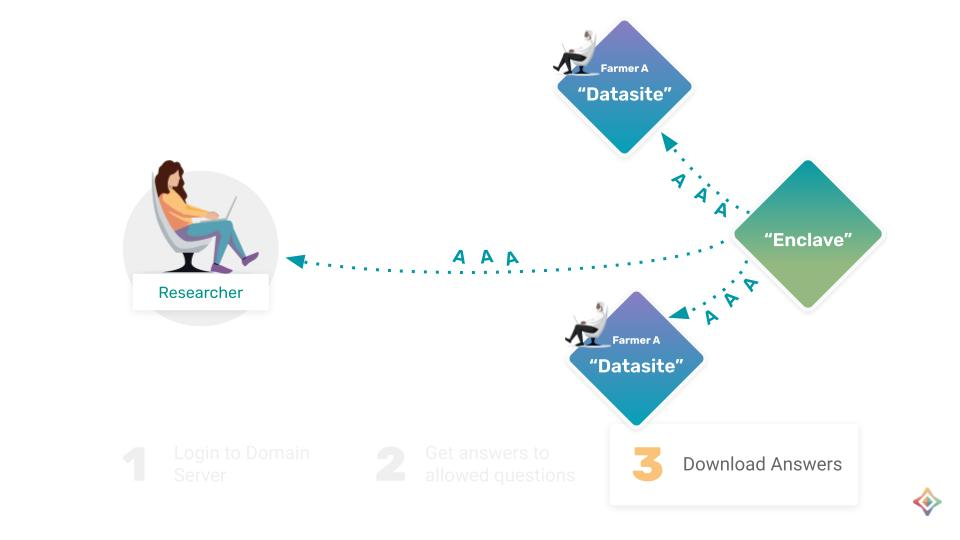

In [23]:
# Wait until the project is ready
proj_res_path = proj_res.output(block=True)

2025-07-18 21:06:44.505 | INFO     | syftbox_enclave.client:output:231 - Waiting for output for project Test Project - 86f7833c...
2025-07-18 21:06:44.507 | INFO     | syftbox_enclave.client:output:236 - Output available for project Test Project - 86f7833c ✅
 Directory: /Users/rasswanths/SyftBox/datasites/enclave-organic-coop@openmined.org/app_data/enclave/jobs/outputs/Test Project - 86f7833c.


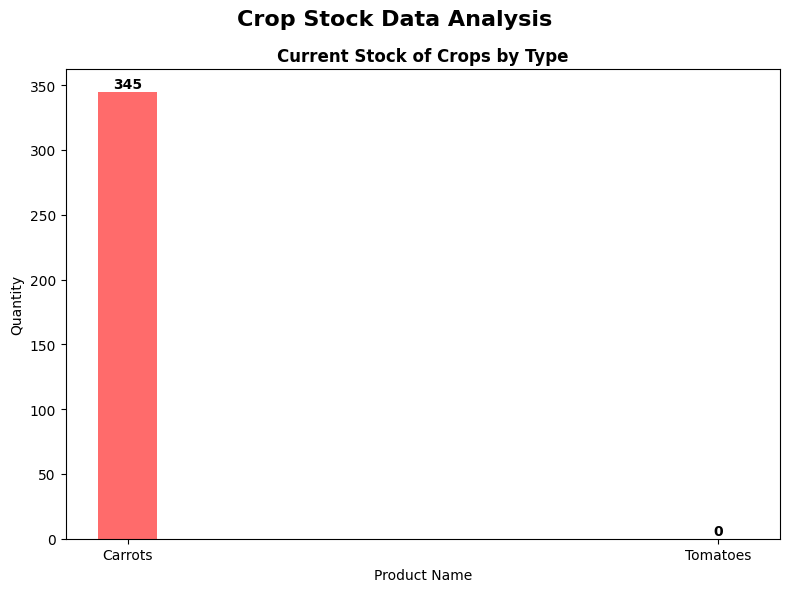

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Set the path to the output.csv
output_csv_path = proj_res_path / "output.csv"

# Set up the plotting style
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Crop Stock Data Analysis', fontsize=16, fontweight='bold')

# Load data
if output_csv_path.exists():
    df = pd.read_csv(output_csv_path)

    # Positions for bars
    x = np.arange(len(df))  # [0, 1, 2, ...]
    width = 0.1

    # Plot bars with fixed width and controlled spacing
    bars = ax.bar(x, df["Quantity"], width=width, color=['#FF6B6B', '#4ECDC4'])

    ax.set_title('Current Stock of Crops by Type', fontweight='bold')
    ax.set_xlabel('Product Name')
    ax.set_ylabel('Quantity')

    # Set x-ticks to product names
    ax.set_xticks(x)
    ax.set_xticklabels(df["Product name"])
    ax.tick_params(axis='x', rotation=0)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No crop stock data available to visualize.")